In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df_races = pd.read_csv("1-Formula_One/races.csv")


In [4]:
#check the rows and headings 
df_races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [5]:
#replace \N into NA
df_races = df_races.replace("\\N", np.nan)

In [6]:
#convert date to date value using for loop
date_col = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]

for col in date_col:
    df_races[col] = pd.to_datetime(df_races[col])

In [7]:
#delete unnecessary column - the fp1, fp2, fp3, quali, and sprint data are mostly missing and therefore we decided to exclude it
df_races = df_races[["raceId", "year"]]


In [8]:
drivers = pd.read_csv("1-Formula_One/drivers.csv")

display(drivers)

drivers_nonnumeric = drivers.query("number.str.isnumeric() == False")
non_number_vals = pd.unique(drivers_nonnumeric["number"])

print(non_number_vals)

replace_vals = [np.nan]

drivers["number"] = drivers["number"].replace(non_number_vals, replace_vals)

drivers["number"] = pd.to_numeric(drivers["number"])

display(drivers)

drivers = drivers[["driverId", "forename", "surname", "nationality", "dob"]]

display(drivers)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
849,851,aitken,89,AIT,Jack,Aitken,1995-09-23,British,http://en.wikipedia.org/wiki/Jack_Aitken
850,852,tsunoda,22,TSU,Yuki,Tsunoda,2000-05-11,Japanese,http://en.wikipedia.org/wiki/Yuki_Tsunoda
851,853,mazepin,9,MAZ,Nikita,Mazepin,1999-03-02,Russian,http://en.wikipedia.org/wiki/Nikita_Mazepin
852,854,mick_schumacher,47,MSC,Mick,Schumacher,1999-03-22,German,http://en.wikipedia.org/wiki/Mick_Schumacher


['\\N']


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
849,851,aitken,89.0,AIT,Jack,Aitken,1995-09-23,British,http://en.wikipedia.org/wiki/Jack_Aitken
850,852,tsunoda,22.0,TSU,Yuki,Tsunoda,2000-05-11,Japanese,http://en.wikipedia.org/wiki/Yuki_Tsunoda
851,853,mazepin,9.0,MAZ,Nikita,Mazepin,1999-03-02,Russian,http://en.wikipedia.org/wiki/Nikita_Mazepin
852,854,mick_schumacher,47.0,MSC,Mick,Schumacher,1999-03-22,German,http://en.wikipedia.org/wiki/Mick_Schumacher


,driverId,forename,surname,nationality,dob
0,1,Lewis,Hamilton,British,1985-01-07
1,2,Nick,Heidfeld,German,1977-05-10
2,3,Nico,Rosberg,German,1985-06-27
3,4,Fernando,Alonso,Spanish,1981-07-29
4,5,Heikki,Kovalainen,Finnish,1981-10-19
...,...,...,...,...,...
849,851,Jack,Aitken,British,1995-09-23
850,852,Yuki,Tsunoda,Japanese,2000-05-11
851,853,Nikita,Mazepin,Russian,1999-03-02
852,854,Mick,Schumacher,German,1999-03-22


In [9]:
results = pd.read_csv("1-Formula_One/results.csv")

display(results)

results_nonnumeric = results.query("position.str.isnumeric() == False")
non_number_vals = pd.unique(results_nonnumeric["position"])

print(non_number_vals)

replace_vals = [np.nan]

results["position"] = results["position"].replace(non_number_vals, replace_vals)

results["position"] = pd.to_numeric(results["position"])

display(results)

results = results[["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "points"]]

display(results)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,20,13,16,16,16,0.0,69,\N,\N,37,15,1:23.511,188.856,11
25656,25662,1086,848,3,23,17,17,17,17,0.0,69,\N,\N,43,12,1:23.047,189.911,11
25657,25663,1086,849,3,6,19,18,18,18,0.0,69,\N,\N,60,8,1:22.478,191.221,11
25658,25664,1086,852,213,22,16,19,19,19,0.0,68,\N,\N,58,16,1:23.538,188.795,12


['\\N']


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1.0,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2.0,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3.0,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4.0,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5.0,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,20,13,16.0,16,16,0.0,69,\N,\N,37,15,1:23.511,188.856,11
25656,25662,1086,848,3,23,17,17.0,17,17,0.0,69,\N,\N,43,12,1:23.047,189.911,11
25657,25663,1086,849,3,6,19,18.0,18,18,0.0,69,\N,\N,60,8,1:22.478,191.221,11
25658,25664,1086,852,213,22,16,19.0,19,19,0.0,68,\N,\N,58,16,1:23.538,188.795,12


,resultId,raceId,driverId,constructorId,grid,positionOrder,points
0,1,18,1,1,1,1,10.0
1,2,18,2,2,5,2,8.0
2,3,18,3,3,7,3,6.0
3,4,18,4,4,11,4,5.0
4,5,18,5,1,3,5,4.0
...,...,...,...,...,...,...,...
25655,25661,1086,825,210,13,16,0.0
25656,25662,1086,848,3,17,17,0.0
25657,25663,1086,849,3,19,18,0.0
25658,25664,1086,852,213,16,19,0.0


In [10]:
df_constructors = pd.read_csv("1-Formula_One/constructors.csv")

df_constructors = df_constructors[["constructorId", "constructorRef"]]

In [20]:
#merging results.csv and drivers.csv
df_merged_drivers_results = pd.merge(left = results, right = drivers, how = "left", on = "driverId")

#merging with constructor.csv
df_merged_constructor_results = pd.merge(left = df_merged_drivers_results, right = df_constructors, how = "left", on = "constructorId") 

#merging with races.csv
df_merged = pd.merge(left = df_merged_constructor_results, right = df_races, how = "left", on = "raceId")

display(df_merged)



,resultId,raceId,driverId,constructorId,grid,positionOrder,points,forename,surname,nationality,dob,constructorRef,year
0,1,18,1,1,1,1,10.0,Lewis,Hamilton,British,1985-01-07,mclaren,2008
1,2,18,2,2,5,2,8.0,Nick,Heidfeld,German,1977-05-10,bmw_sauber,2008
2,3,18,3,3,7,3,6.0,Nico,Rosberg,German,1985-06-27,williams,2008
3,4,18,4,4,11,4,5.0,Fernando,Alonso,Spanish,1981-07-29,renault,2008
4,5,18,5,1,3,5,4.0,Heikki,Kovalainen,Finnish,1981-10-19,mclaren,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,13,16,0.0,Kevin,Magnussen,Danish,1992-10-05,haas,2022
25656,25662,1086,848,3,17,17,0.0,Alexander,Albon,Thai,1996-03-23,williams,2022
25657,25663,1086,849,3,19,18,0.0,Nicholas,Latifi,Canadian,1995-06-29,williams,2022
25658,25664,1086,852,213,16,19,0.0,Yuki,Tsunoda,Japanese,2000-05-11,alphatauri,2022


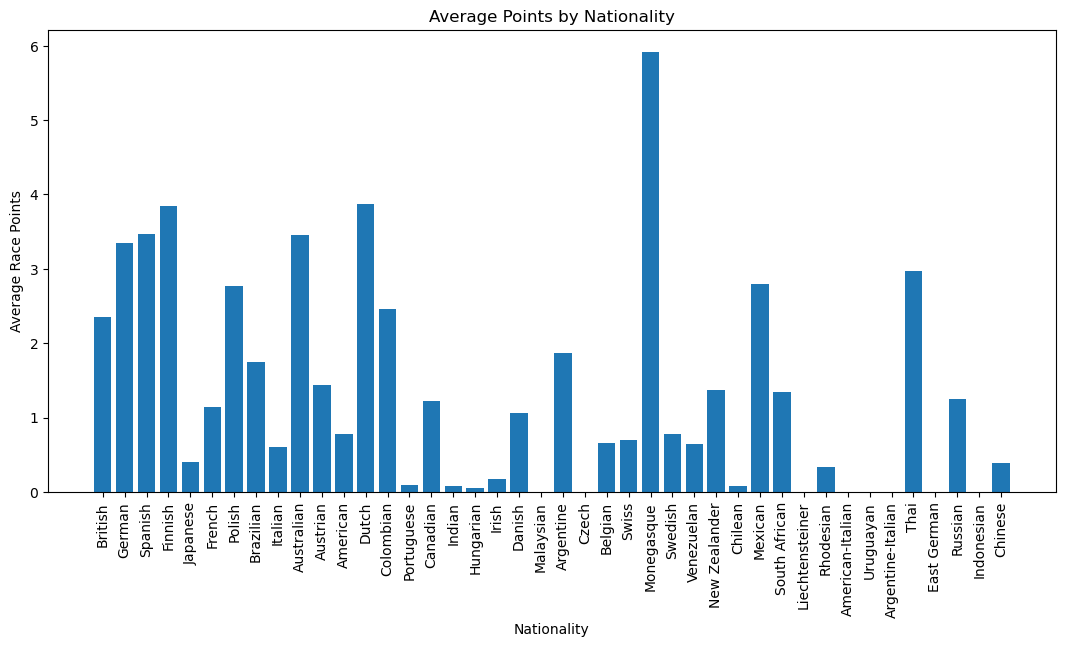

In [28]:
nationalities = pd.unique(df_merged["nationality"])


nationality_list = []
avg_points_list = []

for nationality in nationalities:
    df_nationality = df_merged.query("nationality == @nationality")
    
    total_points = df_nationality["points"].sum()
    num_drivers = len(df_nationality)
    avg_points = total_points / num_drivers
    
    nationality_list.append(nationality)
    avg_points_list.append(avg_points)

plt.figure(figsize=(13, 6))

plt.bar(nationality_list, avg_points_list)

plt.xlabel("Nationality")
plt.ylabel("Average Race Points")
plt.title("Average Points by Nationality")

plt.xticks(rotation=90)


plt.show()

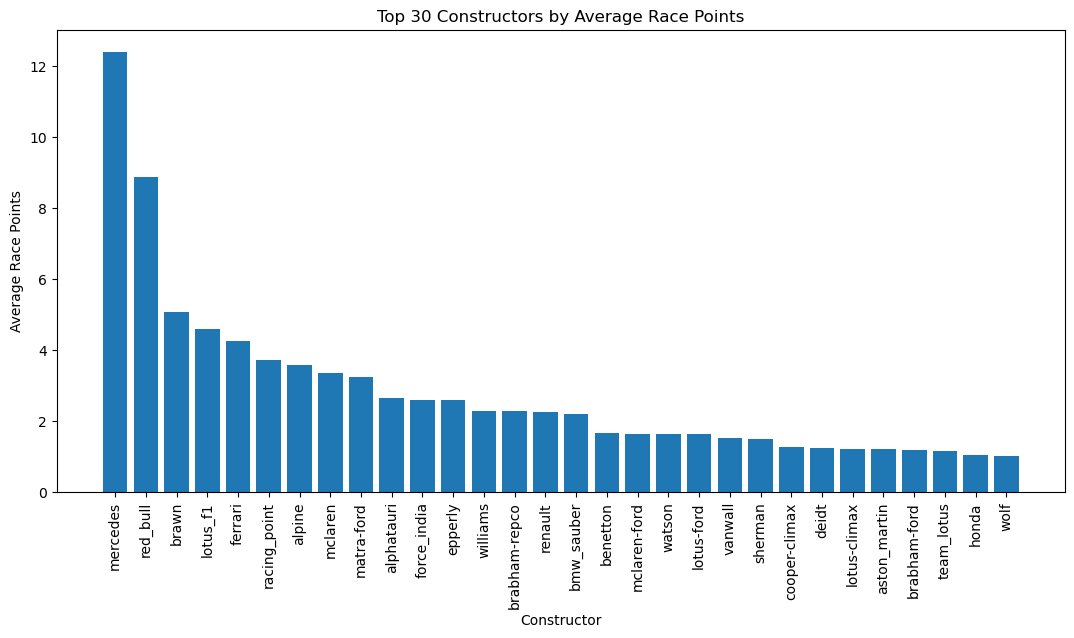

In [ ]:
constructors = pd.unique(df_merged["constructorRef"])

constructor_list = []
avg_points_list = []

for constructor in constructors:
    df_constructor = df_merged.query("constructorRef ==   @constructor")
    
    total_points = df_constructor["points"].sum()
    num_rows =  len(df_constructor)
    avg_points = total_points / num_rows
    
    constructor_list.append(constructor)
    avg_points_list.append(avg_points)


top_constructor_list = []
top_avg_points_list = []

for num in range(30):
    max_points = max(avg_points_list)

    max_index =  avg_points_list.index(max_points)
    
    top_constructor_list.append(constructor_list[max_index])
    top_avg_points_list.append(avg_points_list[max_index])
    
    constructor_list.pop(max_index)
    avg_points_list.pop(max_index)


plt.figure(figsize=(13, 6))

plt.bar(top_constructor_list, top_avg_points_list)

plt.xlabel("Constructor")
plt.ylabel("Average Race Points")
plt.title("Top 30 Constructors by Average Race Points")

plt.xticks(rotation=90) 

plt.show()

,dob,dob_year,year,age
0,1985-01-07,1985,2008,23
1,1977-05-10,1977,2008,31
2,1985-06-27,1985,2008,23
3,1981-07-29,1981,2008,27
4,1981-10-19,1981,2008,27
...,...,...,...,...
25655,1992-10-05,1992,2022,30
25656,1996-03-23,1996,2022,26
25657,1995-06-29,1995,2022,27
25658,2000-05-11,2000,2022,22


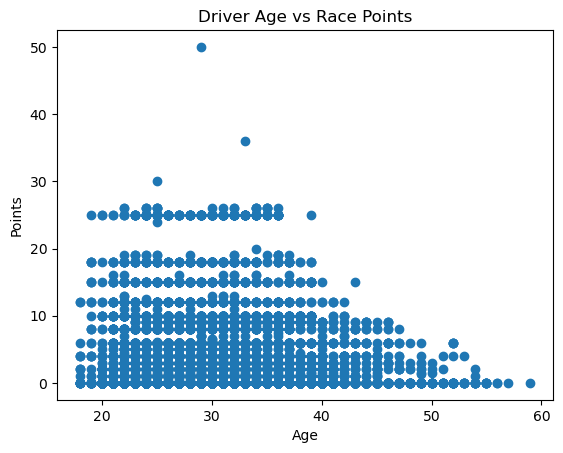

In [31]:
df_merged["dob_year"] = df_merged["dob"].str[0:4]
df_merged["dob_year"] = pd.to_numeric(df_merged["dob_year"])
df_merged["age"] = df_merged["year"] - df_merged["dob_year"]
display(df_merged[["dob", "dob_year", "year", "age"]])

plt.scatter(df_merged["age"], df_merged["points"])

plt.xlabel("Age")
plt.ylabel("Points")
plt.title("Driver Age vs Race Points")

plt.show()

In [ ]:
display(df_merged)

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,forename,surname,nationality,dob,constructorRef,year,dob_year,age
0,1,18,1,1,1,1,10.0,Lewis,Hamilton,British,1985-01-07,mclaren,2008,1985,23
1,2,18,2,2,5,2,8.0,Nick,Heidfeld,German,1977-05-10,bmw_sauber,2008,1977,31
2,3,18,3,3,7,3,6.0,Nico,Rosberg,German,1985-06-27,williams,2008,1985,23
3,4,18,4,4,11,4,5.0,Fernando,Alonso,Spanish,1981-07-29,renault,2008,1981,27
4,5,18,5,1,3,5,4.0,Heikki,Kovalainen,Finnish,1981-10-19,mclaren,2008,1981,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,13,16,0.0,Kevin,Magnussen,Danish,1992-10-05,haas,2022,1992,30
25656,25662,1086,848,3,17,17,0.0,Alexander,Albon,Thai,1996-03-23,williams,2022,1996,26
25657,25663,1086,849,3,19,18,0.0,Nicholas,Latifi,Canadian,1995-06-29,williams,2022,1995,27
25658,25664,1086,852,213,16,19,0.0,Yuki,Tsunoda,Japanese,2000-05-11,alphatauri,2022,2000,22
